In [1]:
!nvidia-smi

Wed Jul  1 16:59:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!wget https://bitbucket.org/ishaanjav/code-and-deploy-custom-tensorflow-lite-model/raw/a4febbfee178324b2083e322cdead7465d6fdf95/fruits.zip

--2026-07-01 16:59:19--  https://bitbucket.org/ishaanjav/code-and-deploy-custom-tensorflow-lite-model/raw/a4febbfee178324b2083e322cdead7465d6fdf95/fruits.zip
Resolving bitbucket.org (bitbucket.org)... 104.192.142.24, 104.192.142.25, 104.192.142.26, ...
Connecting to bitbucket.org (bitbucket.org)|104.192.142.24|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-07-01 16:59:20 ERROR 404: Not Found.



In [10]:
!unzip fruits.zip

Archive:  fruits.zip
   creating: fruits/
  inflating: __MACOSX/._fruits       
  inflating: fruits/.DS_Store        
  inflating: __MACOSX/fruits/._.DS_Store  
   creating: fruits/test/
   creating: fruits/train/
   creating: fruits/validation/
   creating: fruits/test/apple/
  inflating: fruits/test/.DS_Store   
  inflating: __MACOSX/fruits/test/._.DS_Store  
   creating: fruits/test/banana/
   creating: fruits/test/orange/
   creating: fruits/train/apple/
  inflating: fruits/train/.DS_Store  
  inflating: __MACOSX/fruits/train/._.DS_Store  
   creating: fruits/train/banana/
   creating: fruits/train/orange/
   creating: fruits/validation/apple/
  inflating: fruits/validation/.DS_Store  
  inflating: __MACOSX/fruits/validation/._.DS_Store  
   creating: fruits/validation/banana/
   creating: fruits/validation/orange/
  inflating: fruits/test/apple/Screen Shot 2018-06-08 at 5.27.19 PM.png  
  inflating: __MACOSX/fruits/test/apple/._Screen Shot 2018-06-08 at 5.27.19 PM.png  
  inflatin

In [11]:
import tensorflow as tf
import matplotlib.pyplot as plt


In [12]:
tf.__version__

'2.20.0'

In [13]:
img_height, img_width = 32, 32
batch_size = 20

train_ds = tf.keras.utils.image_dataset_from_directory(
    "fruits/train",
    image_size = (img_height, img_width),
    batch_size = batch_size
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    "fruits/validation",
    image_size = (img_height, img_width),
    batch_size = batch_size
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    "fruits/test",
    image_size = (img_height, img_width),
    batch_size = batch_size
)

Found 460 files belonging to 3 classes.
Found 66 files belonging to 3 classes.
Found 130 files belonging to 3 classes.


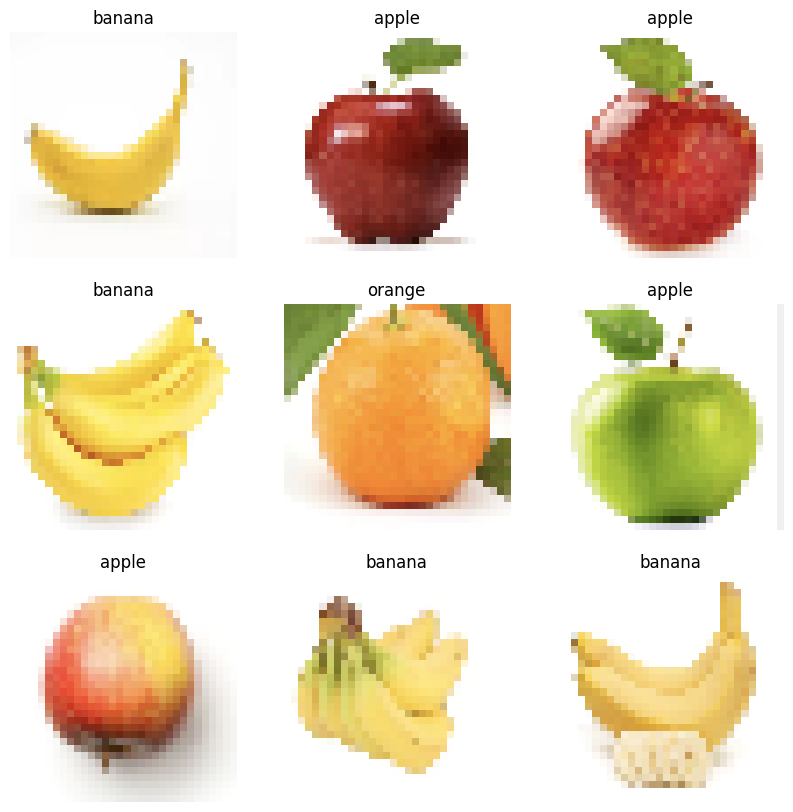

In [14]:
class_names = ['apple','banana','orange']
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i +1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [15]:
model= tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='softmax'),
    tf.keras.layers.Dense(3)
])

In [16]:
model.compile(
    optimizer='rmsprop',
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [17]:
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - accuracy: 0.3652 - loss: 1.0978 - val_accuracy: 0.3333 - val_loss: 1.0944
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - accuracy: 0.4217 - loss: 1.0771 - val_accuracy: 0.3485 - val_loss: 1.0825
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - accuracy: 0.5391 - loss: 1.0170 - val_accuracy: 0.4545 - val_loss: 1.0027
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.6522 - loss: 0.9705 - val_accuracy: 0.4697 - val_loss: 1.0138
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.7217 - loss: 0.9462 - val_accuracy: 0.6212 - val_loss: 0.9367
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.7543 - loss: 0.9139 - val_accuracy: 0.7727 - val_loss: 0.8770
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.7739 - loss: 0.8900 - val_accuracy: 0.8485 - val_loss: 0.8494
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.7783 - loss: 0.8785 - val_accuracy: 0.9242 

In [18]:
model.evaluate(test_ds)

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 595ms/step - accuracy: 0.9462 - loss: 0.5782


[0.5781790018081665, 0.9461538195610046]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step


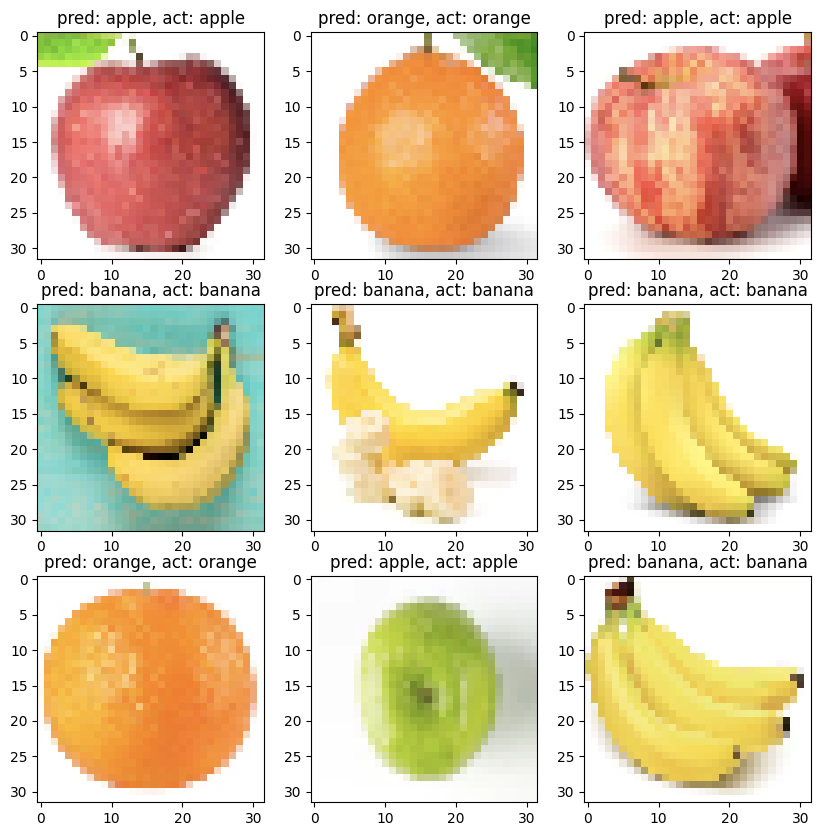

In [19]:
import numpy

plt.figure(figsize=(10, 10))

for images, labels in test_ds.take(1):
  classification = model.predict(images)

for i in range(9):
  ax = plt.subplot(3, 3, i +1)
  plt.imshow(images[i].numpy().astype("uint8"))
  index= numpy.argmax(classification[i])
  plt.title("pred: "+class_names[index]+", act: "+class_names[labels[i]])


In [20]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("model.tflite", 'wb') as f:
  f.write(tflite_model)

Saved artifact at '/tmp/tmpf8zkmn3_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  138758182312208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138758182315280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138758182315472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138758182316432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138758182316048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138758182317008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138758182315856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138758182317968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138758182317392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138758182318928: TensorSpec(shape=(), dtype=tf.resource, name=None)
